In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter

def design_filter(cutoff_hz, sampling_freq, filter_type='low', n=2):
    """
    Проектирование фильтра Баттерворта и вывод его характеристик
    
    Parameters:
    -----------
    cutoff_hz : float
        Частота среза в Гц
    sampling_freq : float
        Частота дискретизации в Гц
    filter_type : str
        'low' или 'high'
    n : int
        Порядок фильтра (по умолчанию 2)
    """
    
    print(f"\n{'='*60}")
    print(f"ФИЛЬТР: {filter_type.upper()}ПРОПУСКАЮЩИЙ")
    print(f"Частота среза: {cutoff_hz} Гц")
    print(f"Частота дискретизации: {sampling_freq} Гц")
    print(f"Порядок фильтра: {n}")
    print(f"{'='*60}\n")
    
    # 1. Расчет коэффициентов
    b_sys, a_sys = butter(n, cutoff_hz, btype=filter_type, analog=False, fs=sampling_freq)
    
    b = b_sys
    a = -a_sys
    
    print(f"Коэффициенты b_i: {b}")
    print(f"Коэффициенты a_i: {a}")
    print(f"\nРазностное уравнение:")
    print(f"y[n] = {b[0]:.8f}*x[n] + {a[1]:.8f}*y[n-1] + {b[1]:.8f}*x[n-1] + {a[2]:.8f}*y[n-2] + {b[2]:.8f}*x[n-2]")
    print("-"*60)
    
    # 2. Расчет и построение АЧХ
    frequencies = np.linspace(0, sampling_freq / 2, 2000)
    w = 2 * np.pi * frequencies / sampling_freq
    
    z1 = np.exp(-1j * w)
    z2 = np.exp(-2j * w)
    
    # Переворачиваем знаки a_i для математической формулы H(z)
    # В разностном уравнении: a[0]*y[n] + a[1]*y[n-1] + a[2]*y[n-2] = b[0]*x[n] + b[1]*x[n-1] + b[2]*x[n-2]
    # В H(z): H(z) = (b[0] + b[1]*z^-1 + b[2]*z^-2) / (a[0] + a[1]*z^-1 + a[2]*z^-2)
    # где a[0] = 1
    a1_math = -a[1]  # a[1] = -a1_math
    a2_math = -a[2]  # a[2] = -a2_math
    
    numerator = b[0] + b[1] * z1 + b[2] * z2
    denominator = 1 + a1_math * z1 + a2_math * z2
    H = numerator / denominator
    
    magnitude = np.abs(H)
    magnitude_db = 20 * np.log10(magnitude + 1e-10)
    
    # 3. Построение графика АЧХ
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    
    # Линейный масштаб
    ax1.plot(frequencies, magnitude, 'b-', linewidth=2)
    ax1.axvline(cutoff_hz, color='r', linestyle='--', label=f'Частота среза ({cutoff_hz} Гц)')
    ax1.set_title(f'АЧХ {filter_type.upper()}ПРОПУСКАЮЩЕГО ФИЛЬТРА Баттерворта {n}-го порядка')
    ax1.set_ylabel('Амплитудный коэффициент')
    ax1.grid(True)
    ax1.legend()
    ax1.set_xlim(0, min(sampling_freq / 2, cutoff_hz*10))  # ограничиваем для наглядности
    
    # Логарифмический масштаб (дБ)
    ax2.plot(frequencies, magnitude_db, 'g-', linewidth=2)
    ax2.axvline(cutoff_hz, color='r', linestyle='--')
    ax2.axhline(-3, color='grey', linestyle=':', label='Уровень -3 дБ')
    ax2.set_xlabel('Частота (Гц)')
    ax2.set_ylabel('Амплитуда (дБ)')
    ax2.grid(True)
    ax2.legend()
    ax2.set_xlim(0, min(sampling_freq / 2, cutoff_hz*10))
    ax2.set_ylim(-60, 5)
    
    plt.tight_layout()
    plt.show()
    
    return b, a


ФИЛЬТР: LOWПРОПУСКАЮЩИЙ
Частота среза: 35.0 Гц
Частота дискретизации: 250.0 Гц
Порядок фильтра: 2

Коэффициенты b_i: [0.11735104 0.23470207 0.11735104]
Коэффициенты a_i: [-1.          0.82523238 -0.29463653]

Разностное уравнение:
y[n] = 0.11735104*x[n] + 0.82523238*y[n-1] + 0.23470207*x[n-1] + -0.29463653*y[n-2] + 0.11735104*x[n-2]
------------------------------------------------------------


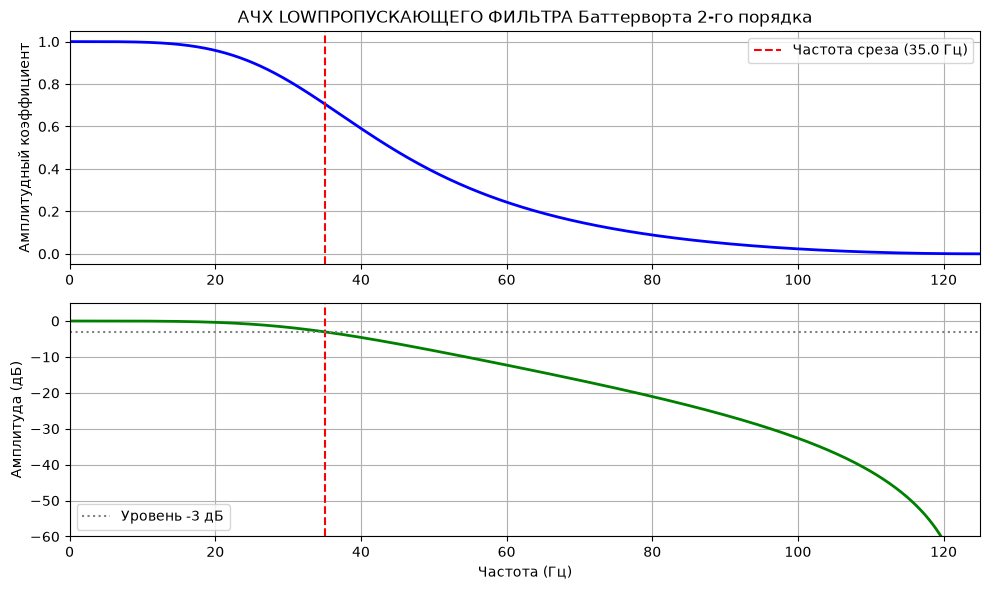

(array([0.11735104, 0.23470207, 0.11735104]),
 array([-1.        ,  0.82523238, -0.29463653]))

In [14]:
design_filter(
        cutoff_hz=35.0,
        sampling_freq=250.0,
        filter_type='low',
        n=2
    )


ФИЛЬТР: HIGHПРОПУСКАЮЩИЙ
Частота среза: 0.9 Гц
Частота дискретизации: 360.0 Гц
Порядок фильтра: 2

Коэффициенты b_i: [ 0.98895425 -1.9779085   0.98895425]
Коэффициенты a_i: [-1.          1.97778648 -0.97803051]

Разностное уравнение:
y[n] = 0.98895425*x[n] + 1.97778648*y[n-1] + -1.97790850*x[n-1] + -0.97803051*y[n-2] + 0.98895425*x[n-2]
------------------------------------------------------------


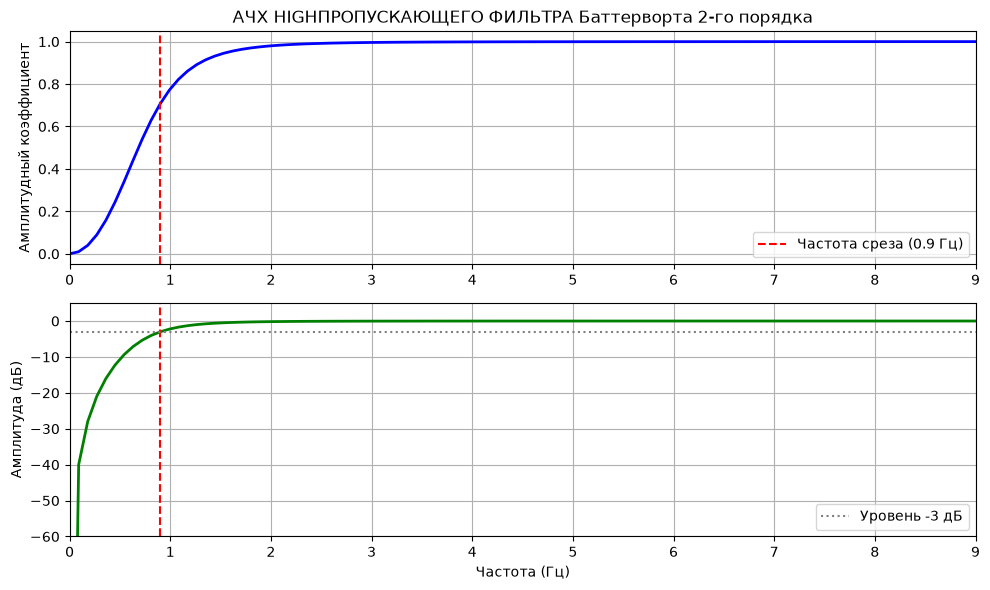

(array([ 0.98895425, -1.9779085 ,  0.98895425]),
 array([-1.        ,  1.97778648, -0.97803051]))

In [13]:
design_filter(
        cutoff_hz=0.9,
        sampling_freq=360.0,
        filter_type='high',
        n=2
    )